In [1]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

!git clone https://github.com/yazeedsn/SSL_SimCLR_Experiment.git
%cd SSL_SimCLR_Experiment
!pip install -r requirements.txt
!pip install -e .

Cloning into 'SSL_SimCLR_Experiment'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 106 (delta 6), reused 11 (delta 3), pack-reused 90 (from 1)
Receiving objects: 100% (106/106), 41.29 MiB | 39.37 MiB/s, done.
Resolving deltas: 100% (47/47), done.
/kaggle/working/SSL_SimCLR_Experiment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 95.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 115.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 26.4 MB/s eta 0:00:00
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2026.1
    Uninstalling tzdata-2026.1:
      Successfully uninstalled tzdata-2026.1
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Suc

In [2]:
import torch
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
from torch.optim import AdamW

from src.losses import nt_xent
from src.models import SimCLR
from src.eval import evaluate_linear_probe
from src.train import train_linear_probe, train_ssl
from src.utils import plot_metric, plot_image_grid, save_model
from src.datasets import get_labeled_ds, get_unlabeled_ds, get_eval_ds
from src.transforms import get_random_augmentation_normalized_transform, get_random_augmentation_transform

In [3]:
SEED = 42
torch.manual_seed(SEED)
generator = torch.Generator()
generator.manual_seed(SEED)

100%|██████████| 2.64G/2.64G [02:12<00:00, 19.9MB/s] 


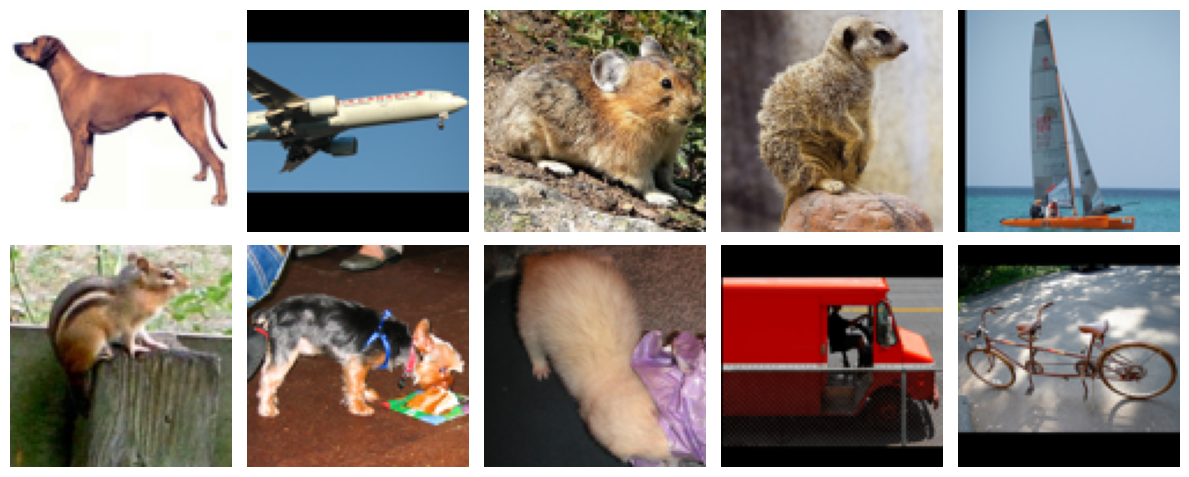

In [4]:
# train represnetions on unlabeled dataset
unlabeled_ds = get_unlabeled_ds()
unlabeled_dl = DataLoader(unlabeled_ds, batch_size=512, shuffle=True, generator=generator)

# perview of the images without augmentations.
imgs, _ = next(iter(unlabeled_dl))
plot_image_grid(imgs, transform=None, save_path='outputs/images_grid.png')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.054415353..1.0000001].


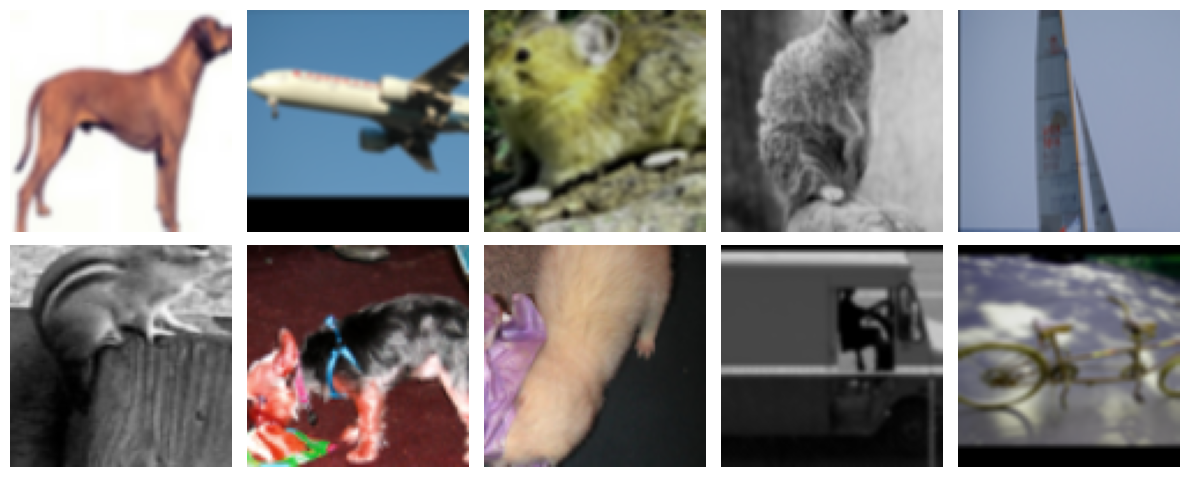

In [5]:
# preview of images with augmentations
tf = get_random_augmentation_transform()
plot_image_grid(imgs, transform=tf, save_path='outputs/images_grid_augmented.png')

In [6]:
!ls outputs/checkpoints

random_resnet18_weights_200_epochs.pth


In [7]:
from torch.optim.lr_scheduler import CosineAnnealingLR

simclr_model = SimCLR()

lr = 5e-4
optimizer = AdamW(simclr_model.parameters(), lr=lr, weight_decay=1e-4)

n_epochs = 200
scheduler = CosineAnnealingLR(optimizer, n_epochs, eta_min=lr/50) 
loss_fn = nt_xent
aug_transform = get_random_augmentation_normalized_transform()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
simclr_model= simclr_model.to(device)
temperature= 0.07

loss_hist_simclr = train_ssl(
    simclr_model,
    unlabeled_dl,
    optimizer,
    aug_transform,
    loss_fn,
    device,
    n_epochs,
    temperature,
    scheduler,
    resume_from_checkpoint=None,#'outputs/checkpoints/sim_clr_cp_epoch_080.pt',
    checkpoint_every=40,
)

Epoch [1/200] Loss: 1.4496: 100%|██████████| 196/196 [03:09<00:00,  1.03it/s]
/kaggle/working/SSL_SimCLR_Experiment/src/train.py:194: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(epoch)



Epoch 1 completed — Avg Loss: 1.4496



Epoch [2/200] Loss: 0.3618: 100%|██████████| 196/196 [03:14<00:00,  1.01it/s]



Epoch 2 completed — Avg Loss: 0.3618



Epoch [3/200] Loss: 0.2657: 100%|██████████| 196/196 [03:14<00:00,  1.01it/s]


...


Epoch 198 completed — Avg Loss: 0.0066



Epoch [199/200] Loss: 0.0058: 100%|██████████| 196/196 [03:14<00:00,  1.01it/s]



Epoch 199 completed — Avg Loss: 0.0058



Epoch [200/200] Loss: 0.0061: 100%|██████████| 196/196 [03:14<00:00,  1.01it/s]


Epoch 200 completed — Avg Loss: 0.0061

Checkpoint saved for epoch 200


In [8]:
save_model(simclr_model, 'simclr')

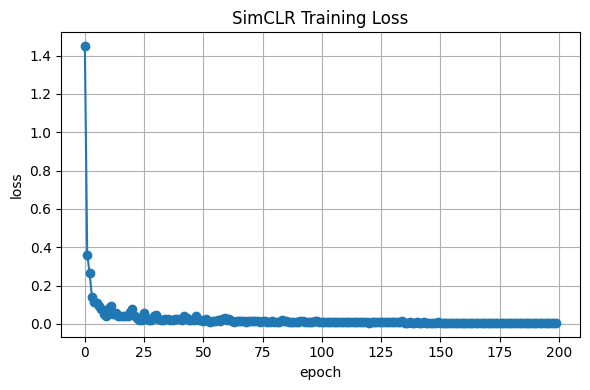

In [9]:
plot_metric(
    loss_hist_simclr,
    list(range(n_epochs)),
    ylabel='loss',
    xlabel='epoch',
    title='SimCLR Training Loss',
    save_path='outputs/simclr_ssl_loss_curve.png'
)

# Training SimCLR For Linear Probing

In [20]:
labeled_ds = get_labeled_ds()
labeled_dl = DataLoader(labeled_ds, batch_size=64, shuffle=True, generator=generator)

In [21]:
from torch import nn

encoder = simclr_model.encoder
for param in encoder.parameters():
    param.requires_grad = False
linear_probe_model = nn.Sequential(
    encoder,
    nn.Flatten(),
    nn.Linear(512, 10),
)

In [22]:
optimizer_factory = lambda p : AdamW(p, lr=3e-4, weight_decay=2e-4)
loss_fn = CrossEntropyLoss()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
n_epochs = 20
linear_probe_model = linear_probe_model.to(device)
loss_hist_simclr_linear_prob, acc_hist_simclr_linear_prob = train_linear_probe(
    linear_probe_model,
    labeled_dl,
    optimizer_factory,
    loss_fn,
    device,
    n_epochs
)

Epoch [1/20] Batch [79/79]: 100%|██████████| 79/79 [00:11<00:00,  6.66it/s, Loss=1.4681]



Epoch 1 completed — Avg Loss: 1.5256 | Avg Acc: 0.4624



Epoch [2/20] Batch [79/79]: 100%|██████████| 79/79 [00:12<00:00,  6.53it/s, Loss=1.6572]



Epoch 2 completed — Avg Loss: 1.2317 | Avg Acc: 0.5656



Epoch [3/20] Batch [79/79]: 100%|██████████| 79/79 [00:11<00:00,  6.64it/s, Loss=1.2672]


...


Epoch 18 completed — Avg Loss: 1.0047 | Avg Acc: 0.6410



Epoch [19/20] Batch [79/79]: 100%|██████████| 79/79 [00:11<00:00,  6.64it/s, Loss=0.8114]



Epoch 19 completed — Avg Loss: 0.9972 | Avg Acc: 0.6386



Epoch [20/20] Batch [79/79]: 100%|██████████| 79/79 [00:11<00:00,  6.69it/s, Loss=1.3634]


Epoch 20 completed — Avg Loss: 0.9886 | Avg Acc: 0.6498



In [23]:
save_model(linear_probe_model, "simclr_linear_prob")

NameError: name 'linear_prob_model' is not defined

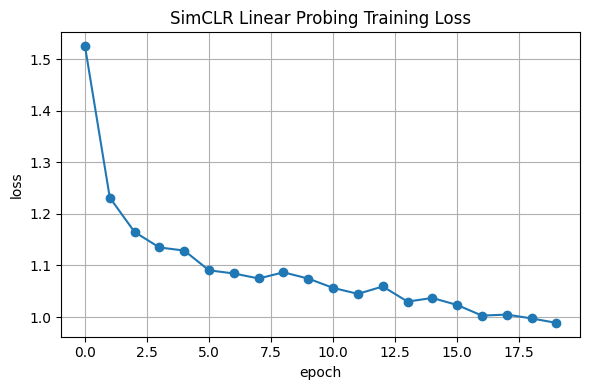

In [24]:
# plot loss
plot_metric(
    loss_hist_simclr_linear_prob,
    list(range(n_epochs)),
    ylabel='loss',
    xlabel='epoch',
    title='SimCLR Linear Probing Training Loss',
    save_path='outputs/simclr_linear_prob_loss_curve.png'

)

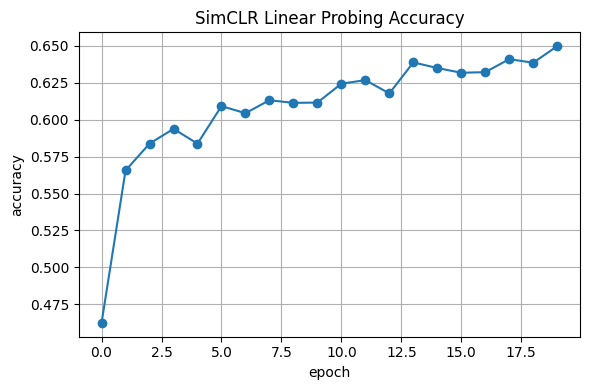

In [25]:
plot_metric(
    acc_hist_simclr_linear_prob,
    list(range(n_epochs)),
    ylabel='accuracy',
    xlabel='epoch',
    title='SimCLR Linear Probing Accuracy',
    save_path='outputs/simclr_acc_curve.png'
)

In [27]:
eval_ds = get_eval_ds()
eval_dl = DataLoader(eval_ds, batch_size=512, shuffle=False)

eval_acc_simclr = evaluate_linear_probe(linear_probe_model, eval_dl, len(eval_ds), device)

Test Accuracy: 0.6224
